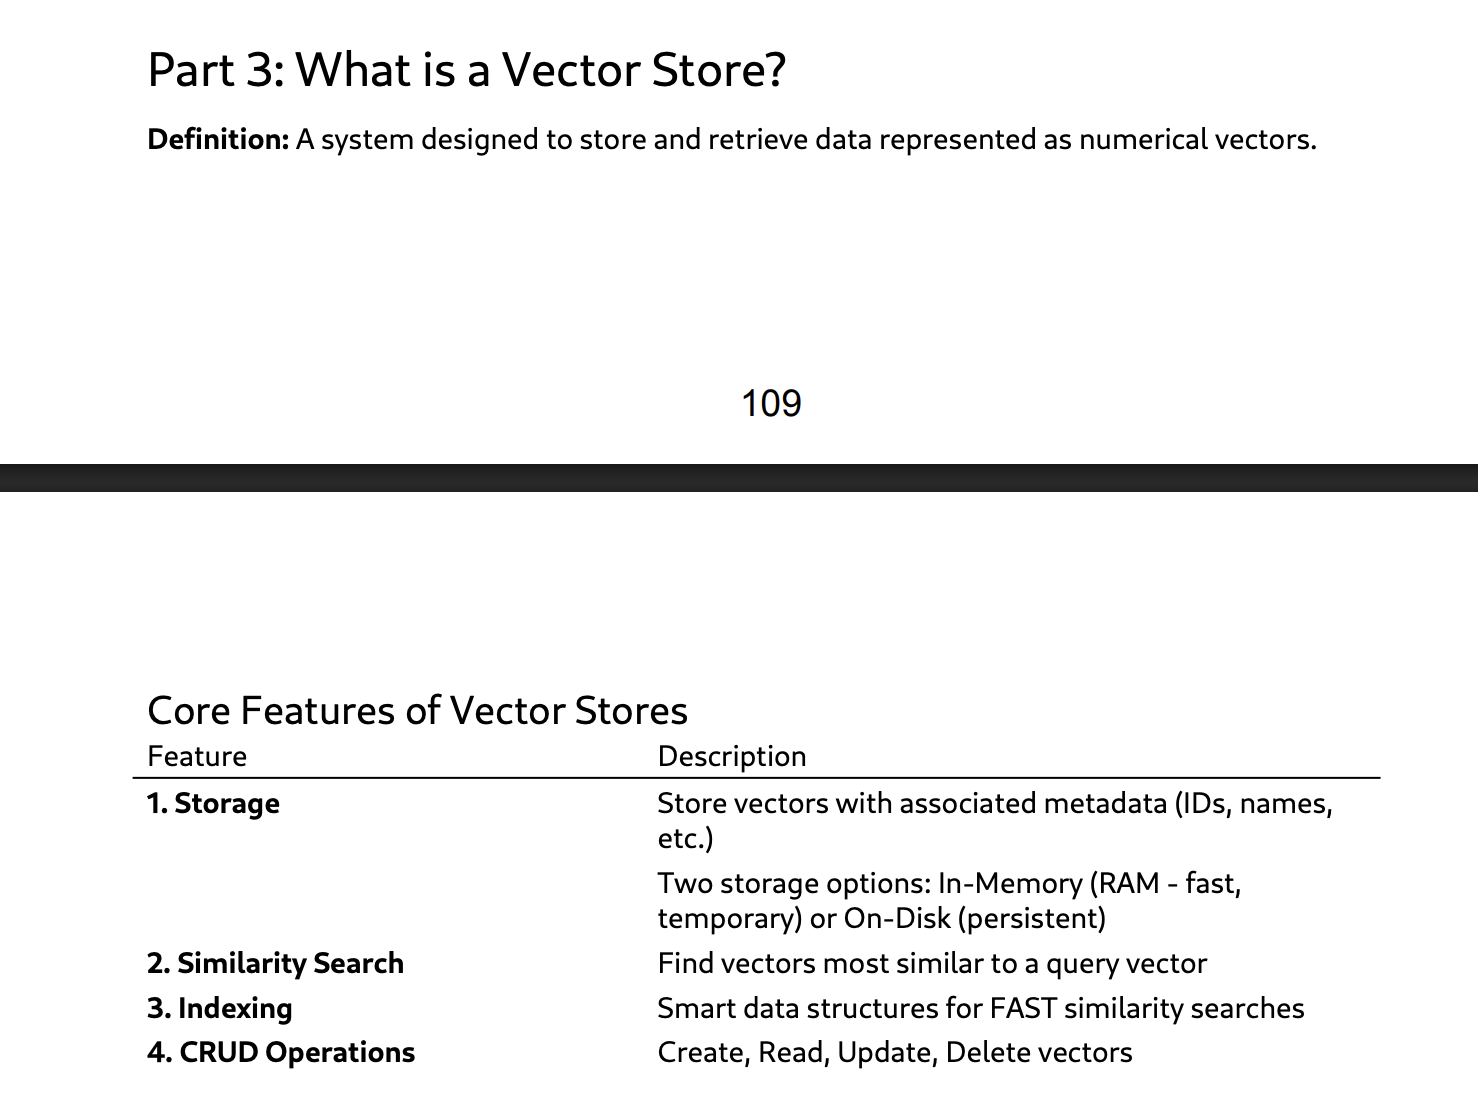

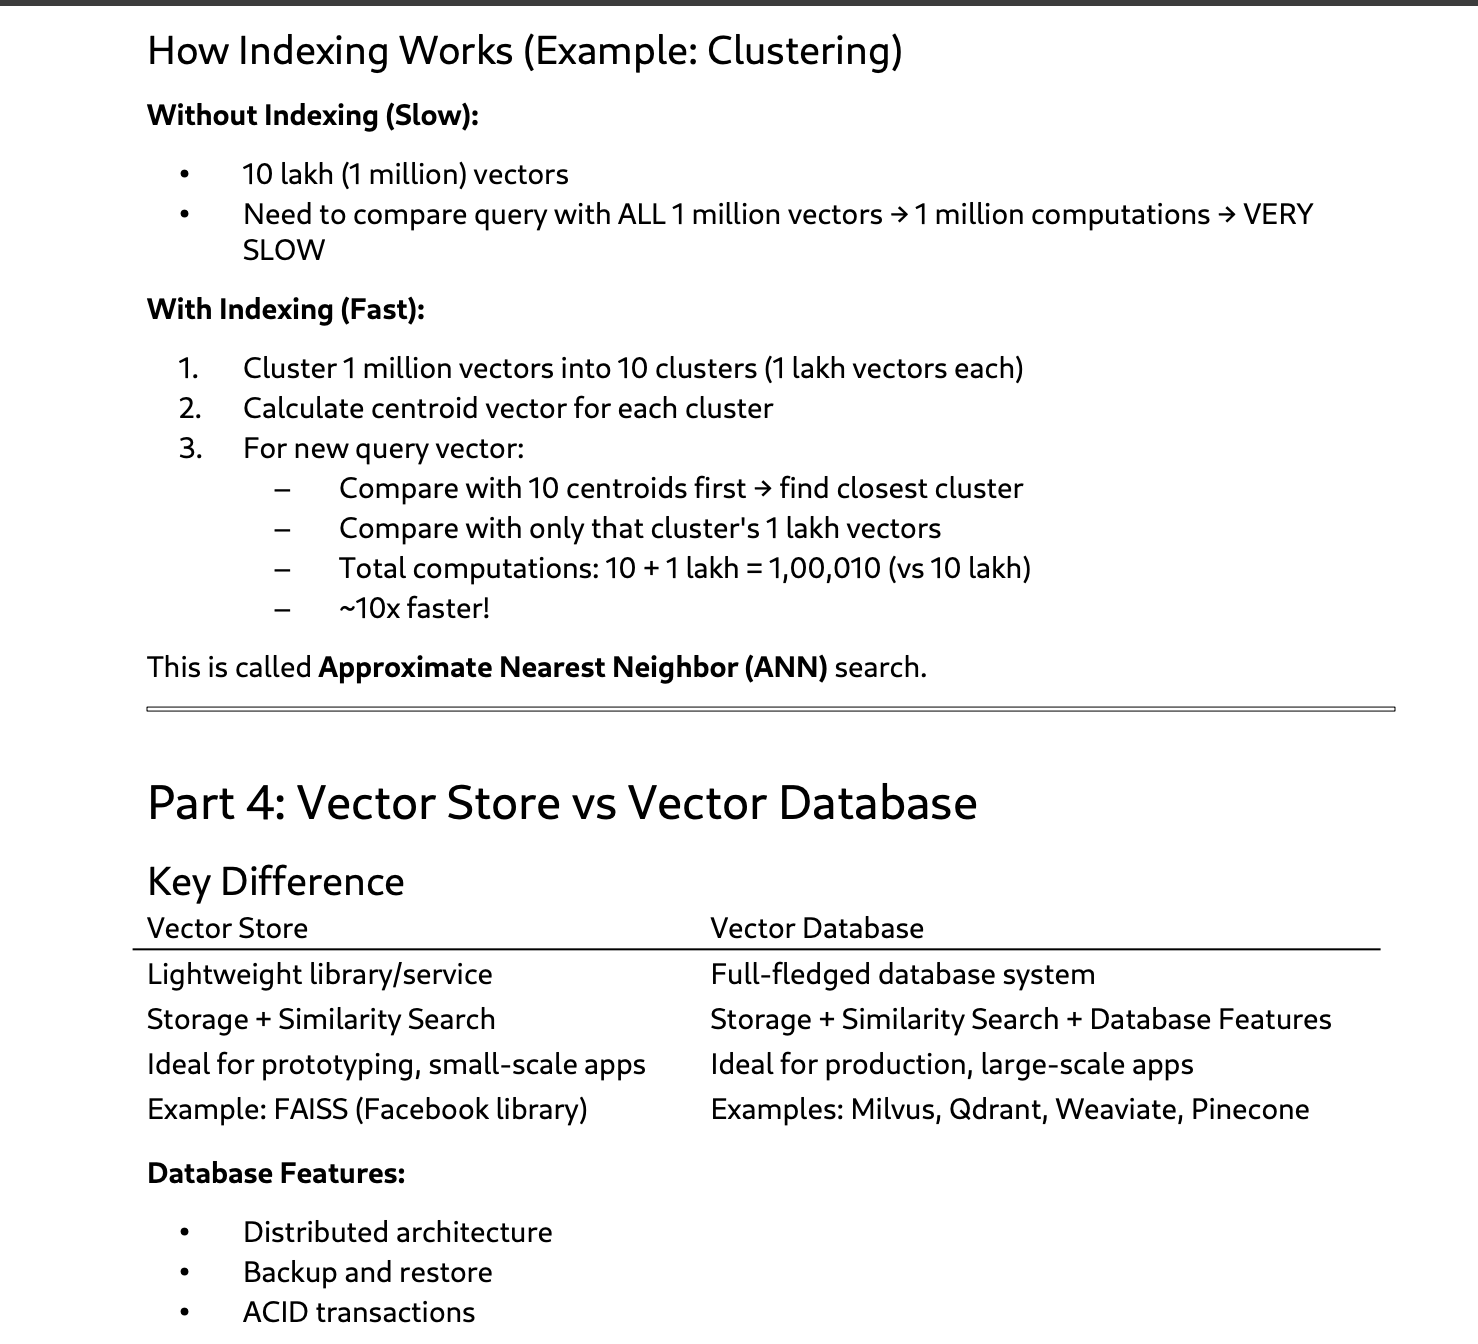

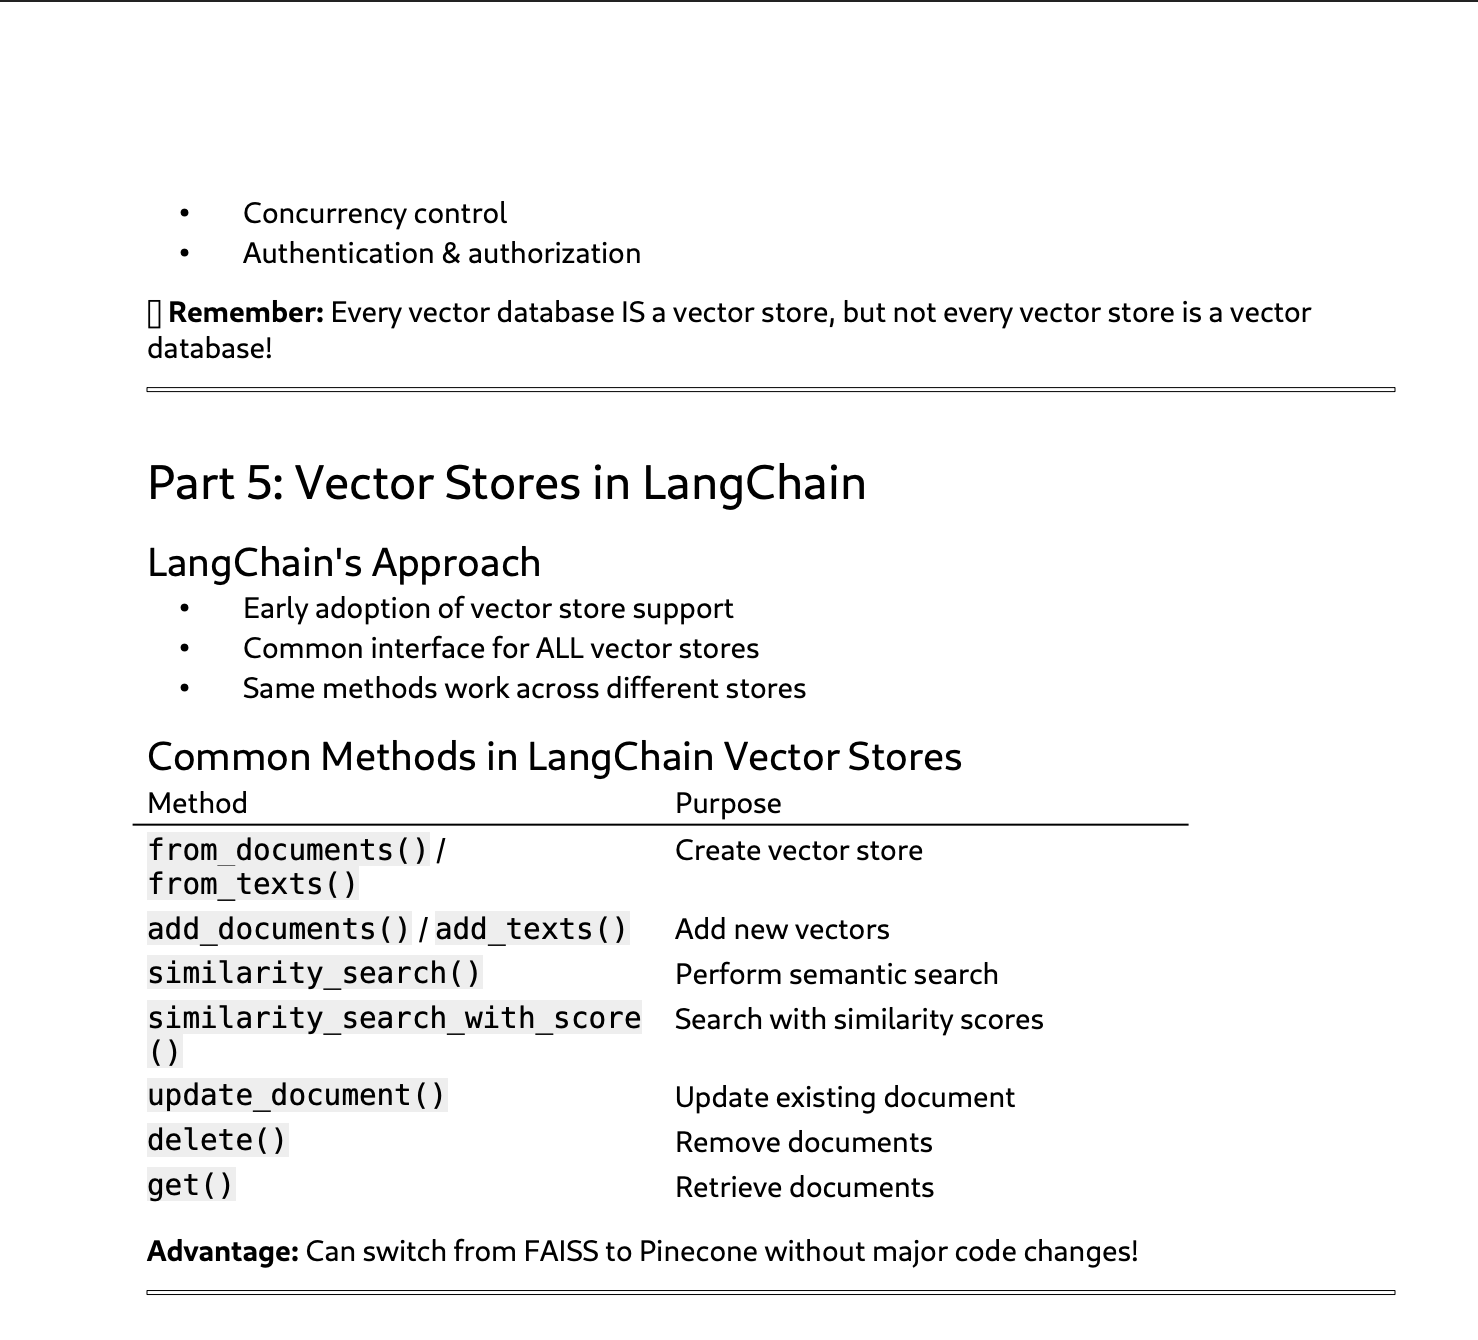

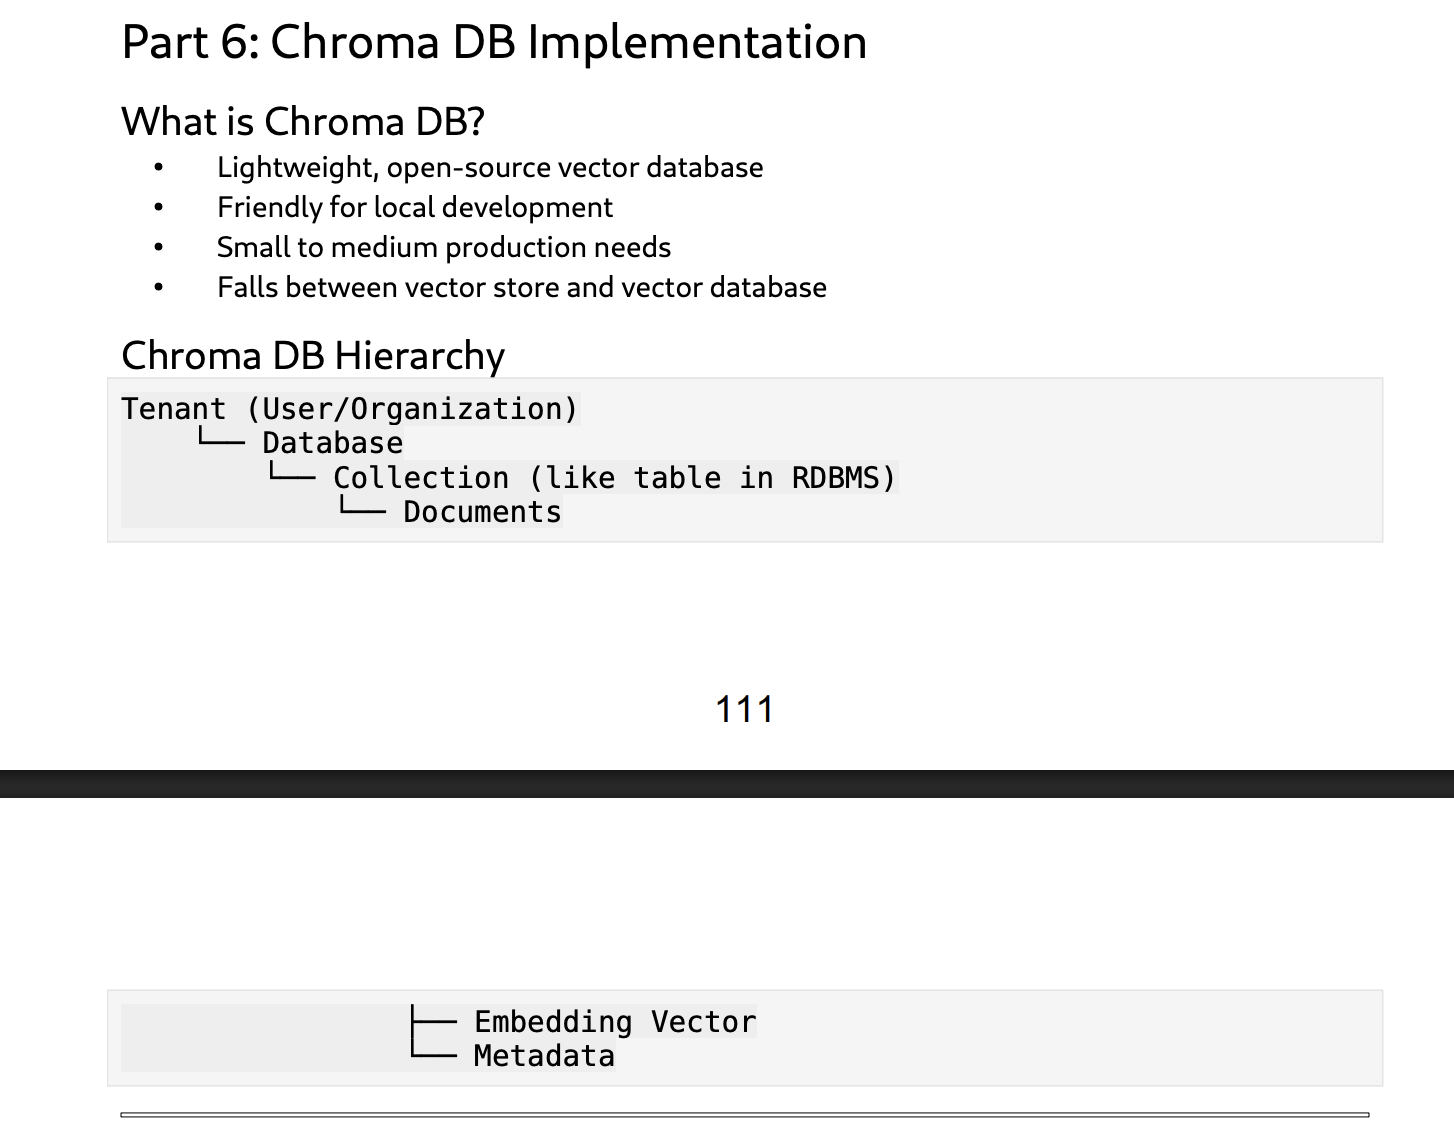

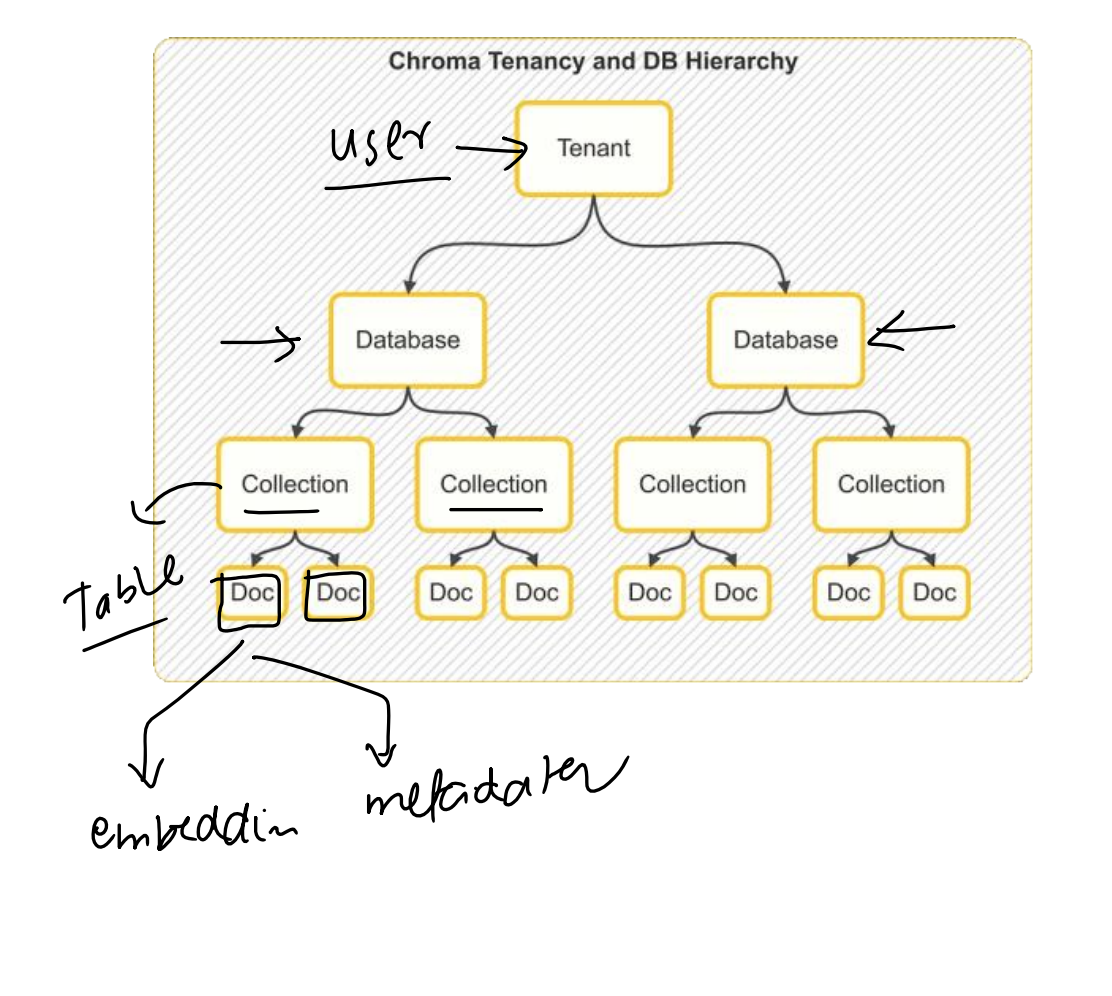

##### Step 1: Install Required Libraries

In [2]:
# pip install langchain-chroma

##### Step 2: Import Libraries

In [18]:
from langchain_chroma import Chroma
from langchain_core.documents import Document

#### Step 3: Create Sample Documents

In [19]:
# Create Document objects (each has page_content and metadata)
doc1 = Document(
 page_content="Virat Kohli is one of the most successful andconsistent batsmen in IPL history. He has scored the most runs in IPL and holds the record for most centuries. He plays for Royal Challengers Bangalore.",
 metadata={"team": "Royal Challengers Bangalore"}
)
doc2 = Document(
 page_content="Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He is known for his elegant batting and leadership skills.",
 metadata={"team": "Mumbai Indians"}
)
doc3 = Document(
 page_content="MS Dhoni, known as Captain Cool, led Chennai SuperKings to multiple IPL titles. He is one of the finest finishers and wicket-keepers in cricket history.",
 metadata={"team": "Chennai Super Kings"}
)
doc4 = Document(
 page_content="Jasprit Bumrah is a world-class fast bowler known for his unique action and death bowling skills. He plays for Mumbai Indians and is a key player for Team India.",
 metadata={"team": "Mumbai Indians"}
)
doc5 = Document(
 page_content="Ravindra Jadeja is a brilliant all-rounder,excellent in fielding, batting, and bowling. He plays for Chennai Super Kings and is known as Sir Jadeja.",
 metadata={"team": "Chennai Super Kings"}
)

In [20]:
# Create a list of all documents
docs = [doc1, doc2, doc3, doc4, doc5]

#### Step 4:Create vector store

In [21]:
# Initialize embeddings 
from langchain_huggingface.embeddings import HuggingFaceEndpointEmbeddings
from dotenv import load_dotenv
import os

load_dotenv()
api_key = os.getenv("Hugging_face_api_token")
hf_embeddings_api = HuggingFaceEndpointEmbeddings(
    model="sentence-transformers/all-MiniLM-L6-v2",  # lightweight
    # model="Qwen/Qwen3-Embedding-8B",
    # task="feature-extraction",# heavyweight but uses a lot of quota token
    huggingfacehub_api_token=api_key,
)

In [22]:
# create vector store
vector_store=Chroma(
    embedding_function=hf_embeddings_api,
    persist_directory="./self_practice_chroma_db",#where to store on disk,
    collection_name="sample" #collection name ~ similar to table in RDBMS
)

##### STEP 5: Add Documents to Vector Store

In [11]:
# add documents to the vector store
added_ids=vector_store.add_documents(docs)

#view the IDs assigned to each document
print("Document IDs:",added_ids)

Document IDs: ['bb04e2e3-36df-43d7-85ec-867223df978a', '3dd660e9-0dee-43ed-af70-41fb10418074', 'c59f394c-78c9-4540-9b9b-8259e3bb4389', '7c09adde-ff59-46ce-b024-79288f665a8e', '51eb2220-f4ec-48a1-8c95-3f43fa98fafa']


In [12]:
print(type(added_ids))

<class 'list'>


In [13]:
added_ids[0]

'bb04e2e3-36df-43d7-85ec-867223df978a'

##### Step 6:View all Documents

In [14]:
#Get all documents with their embeddings and metadata
all_docs=vector_store.get(include=["embeddings","documents","metadatas"])

print(type(all_docs))

<class 'dict'>


In [16]:
all_docs.keys()

dict_keys(['ids', 'embeddings', 'documents', 'uris', 'included', 'data', 'metadatas'])

In [15]:
print("Number of documents: ",len(all_docs["documents"]))
print("\n Documents: ",all_docs["documents"])
print("\n Metadata: ",all_docs["metadatas"])

Number of documents:  5

 Documents:  ['Virat Kohli is one of the most successful andconsistent batsmen in IPL history. He has scored the most runs in IPL and holds the record for most centuries. He plays for Royal Challengers Bangalore.', 'Rohit Sharma is the most successful captain in IPL history, leading Mumbai Indians to five titles. He is known for his elegant batting and leadership skills.', 'MS Dhoni, known as Captain Cool, led Chennai SuperKings to multiple IPL titles. He is one of the finest finishers and wicket-keepers in cricket history.', 'Jasprit Bumrah is a world-class fast bowler known for his unique action and death bowling skills. He plays for Mumbai Indians and is a key player for Team India.', 'Ravindra Jadeja is a brilliant all-rounder,excellent in fielding, batting, and bowling. He plays for Chennai Super Kings and is known as Sir Jadeja.']

 Metadata:  [{'team': 'Royal Challengers Bangalore'}, {'team': 'Mumbai Indians'}, {'team': 'Chennai Super Kings'}, {'team': '

#### Step 7:Similarity Search

In [23]:
# search for documents similar to query
results=vector_store.similarity_search(
    query="Who is a bowler among these?",
    k=1 #Return top 1 result
)

print("Top result: ",results[0].page_content)
print("Metadata: ",results[0].metadata)

Top result:  Jasprit Bumrah is a world-class fast bowler known for his unique action and death bowling skills. He plays for Mumbai Indians and is a key player for Team India.
Metadata:  {'team': 'Mumbai Indians'}


In [24]:
results

[Document(id='7c09adde-ff59-46ce-b024-79288f665a8e', metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is a world-class fast bowler known for his unique action and death bowling skills. He plays for Mumbai Indians and is a key player for Team India.')]

In [25]:
type(results)

list

##### Step8:Search with Multiple Results

In [27]:
# get top 2 similar documents
results=vector_store.similarity_search(
    query="Who is a bowler among these?",
    k=2
)

for i,doc in enumerate(results,1):
    print(f"Result {i}: {doc.page_content[:50]}...")
    print(f"Team: {doc.metadata['team']}\n")

Result 1: Jasprit Bumrah is a world-class fast bowler known ...
Team: Mumbai Indians

Result 2: Ravindra Jadeja is a brilliant all-rounder,excelle...
Team: Chennai Super Kings



#### step 9: search with similarity scores

In [30]:
# search with similarity scores(lower score=more similar)
results_with_scores=vector_store.similarity_search_with_score(
    query="Who is a bowler among these?",
    k=2
)

for doc,score in results_with_scores:
    print(f"Document: {doc.page_content[:50]}...")
    print(f"Similarity Score(distance): {score}")
    print(f"Team: {doc.metadata['team']}\n")

Document: Jasprit Bumrah is a world-class fast bowler known ...
Similarity Score(distance): 1.0419102907180786
Team: Mumbai Indians

Document: Ravindra Jadeja is a brilliant all-rounder,excelle...
Similarity Score(distance): 1.1323232650756836
Team: Chennai Super Kings



In [31]:
print(type(results_with_scores))

<class 'list'>


In [32]:
results_with_scores

[(Document(id='7c09adde-ff59-46ce-b024-79288f665a8e', metadata={'team': 'Mumbai Indians'}, page_content='Jasprit Bumrah is a world-class fast bowler known for his unique action and death bowling skills. He plays for Mumbai Indians and is a key player for Team India.'),
  1.0419102907180786),
 (Document(id='51eb2220-f4ec-48a1-8c95-3f43fa98fafa', metadata={'team': 'Chennai Super Kings'}, page_content='Ravindra Jadeja is a brilliant all-rounder,excellent in fielding, batting, and bowling. He plays for Chennai Super Kings and is known as Sir Jadeja.'),
  1.1323232650756836)]

##### Step 10:Metadata Filtering

In [36]:
# find all the documents where team is "Chennai Super Kings"
filtered_results=vector_store.similarity_search(
    query="",#Empty query - just filter by metadata
    k=10,#Get all matching,
    filter={"team":"Chennai Super Kings"}
)
print("Chennai Super Kings players:")
for doc in filtered_results:
    print(f"- {doc.page_content[:50]}")

Chennai Super Kings players:
- MS Dhoni, known as Captain Cool, led Chennai Super
- Ravindra Jadeja is a brilliant all-rounder,excelle


### STEP 11: CRUD OPERATIONS

#### 11.1: update a Document

In [37]:
#Created updated Document for Virat Kohli
updated_doc=Document(
    page_content="Virat Kohli, the former captain of Royal Challengers Bangalore, is renowned for his aggressive leadership and consistency.He holds multiple IPL batting records.",
    metadata={"team":"Royal Challenger's Bangalore"}
)

#Get Virat's document ID (from earlier step)
virat_id=added_ids[0] # first ID is virat's id

#Update the document
vector_store.update_document(
    document_id=virat_id,
    document=updated_doc
)

#verify update
updated=vector_store.get(ids=[virat_id])
print("updated document: ",updated["documents"][0])

updated document:  Virat Kohli, the former captain of Royal Challengers Bangalore, is renowned for his aggressive leadership and consistency.He holds multiple IPL batting records.


#### 11.2 Delete a Document

In [39]:
# Delete Virat Kohli's document
vector_store.delete(ids=[virat_id])

#check remaining documents
remaining=vector_store.get(include=["documents"])
print(f"Remaining documents: {len(remaining['documents'])}")

Remaining documents: 4
